# DyslexAI — Dataset C: Inspection and Fairness Check

**English handwriting paragraphs (Kaggle, Oussama Slmani)**
**Jira: DYS-5**

---

## What this notebook is for

We have a new dataset. Before we train anything on it, we check whether a score on it would
actually mean anything.

We are **not** training a model here. We are answering one question:

> Can you tell the two classes apart **without reading the handwriting at all**?

If the answer is yes, then any accuracy we report later is partly fake, and we need to know that
before we spend time on it.

## Why this dataset looks promising

The images are **full sentences and paragraphs**, not single letters.

Our earlier experiments on single characters found nothing — no model beat the guess-from-numbers
floor. A single letter does not show spacing, line drift, letter-size consistency, or spelling.
Paragraphs do. So this is a better match for the task.

## Two checks we run

**Check 1 — the size check.** Can you guess the class from image width, height and file size
alone? No pictures involved.

**Check 2 — the appearance check.** Resize everything to the same size and colour format, so all
size information is gone. Then measure simple things like brightness, contrast and sharpness.
Can you still guess the class?

If Check 1 is high but Check 2 is low, the problem is just image size and we can work around it.

If **both** are high, the two classes came from different sources and differ in ways that have
nothing to do with handwriting. That would make the dataset unusable as a fair test.

---

## Before you run

Upload `dyslexic.rar` to `MyDrive/DyslexAI/archives/`.

---
# 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, sys, json, random, subprocess, hashlib
from pathlib import Path
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image, ImageFilter

DRIVE       = Path('/content/drive/MyDrive/DyslexAI')
ARCHIVE_DIR = DRIVE / 'archives'
INTERIM_DIR = DRIVE / 'data' / 'interim'
REPORTS_DIR = DRIVE / 'reports'
FIGURES_DIR = DRIVE / 'results' / 'figures'
RAW_DIR     = Path('/content/raw')

for d in [INTERIM_DIR, REPORTS_DIR, FIGURES_DIR, RAW_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED); np.random.seed(SEED)

print('Python     :', sys.version.split()[0])
print('numpy      :', np.__version__)
print('pandas     :', pd.__version__)
try:
    import torch, torchvision
    print('torch      :', torch.__version__)
    print('torchvision:', torchvision.__version__)
    print('GPU        :', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none')
except ImportError:
    print('torch      : not needed for this notebook')

Python     : 3.13.15
numpy      : 2.1.3
pandas     : 2.2.3
torch      : 2.11.0+cpu
torchvision: 0.26.0+cpu
GPU        : none


In [ ]:
# ---- Unpack -----------------------------------------------------------------
!apt-get -qq install -y libarchive-tools > /dev/null 2>&1

DEST = RAW_DIR / 'dataset_c'
if not any(DEST.rglob('*.jpg')) if DEST.exists() else True:
    DEST.mkdir(parents=True, exist_ok=True)
    subprocess.run(['bsdtar', '-xf', str(ARCHIVE_DIR / 'dyslexic.rar'), '-C', str(DEST)],
                   capture_output=True, check=False)
    print('extracted')
else:
    print('already extracted')

IMG_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}

# Find the folder that holds the class subfolders, rather than assuming a path
def find_class_root(root, expected):
    want = {c.lower() for c in expected}
    for d in [Path(root)] + [p for p in Path(root).rglob('*') if p.is_dir()]:
        kids = {c.name.lower() for c in d.iterdir() if c.is_dir()}
        if want.issubset(kids):
            return d
    raise FileNotFoundError(f'could not find folders {expected} under {root}')

ROOT = find_class_root(DEST, ['yes', 'no'])
print('class folders live in:', ROOT)
for d in sorted(p for p in ROOT.iterdir() if p.is_dir()):
    n = sum(1 for f in d.iterdir() if f.suffix.lower() in IMG_EXT)
    print(f'  {d.name:<6} {n} images')

extracted
class folders live in: /content/raw/dataset_c/dyslexic
  no     50 images
  yes    50 images


---
# 2. What is actually in here

We read every file and record what it is. No assumptions from the folder names or the Kaggle
description.

In [ ]:
rows = []
for cls_dir in sorted(p for p in ROOT.iterdir() if p.is_dir()):
    for f in sorted(cls_dir.iterdir()):
        if f.suffix.lower() not in IMG_EXT:
            continue
        rec = {'class_name': cls_dir.name, 'filename': f.name,
               'filepath': str(f), 'file_size_bytes': f.stat().st_size,
               'sha256': hashlib.sha256(f.read_bytes()).hexdigest(),
               'corrupted': 0}
        try:
            with Image.open(f) as im:
                im.verify()
            with Image.open(f) as im:
                rec['width'], rec['height'] = im.size
                rec['mode'] = im.mode
                rec['channels'] = len(im.getbands())
                rec['file_format'] = im.format
                ex = im.getexif()
                rec['has_exif'] = int(bool(ex))
                im.load()
        except Exception as e:
            rec['corrupted'] = 1
            rec['error'] = str(e)
        rows.append(rec)

meta = pd.DataFrame(rows)
meta['aspect'] = meta['width'] / meta['height']
meta['area']   = meta['width'] * meta['height']
meta['label']  = (meta['class_name'].str.lower() == 'yes').astype(int)

print(f'total images : {len(meta)}')
print(f'corrupted    : {int(meta["corrupted"].sum())}')
print()
print(meta['class_name'].value_counts().to_string())

total images : 100
corrupted    : 0

class_name
no     50
yes    50


In [ ]:
print('=== per class ===')
for cls, sub in meta.groupby('class_name'):
    print(f'\n--- {cls} ({len(sub)} images) ---')
    print(f'  colour modes  : {dict(Counter(sub["mode"]))}')
    print(f'  width         : {sub.width.min()} to {sub.width.max()}')
    print(f'  height        : {sub.height.min()} to {sub.height.max()}')
    print(f'  median area   : {int(sub.area.median()):,} pixels')
    print(f'  aspect ratio  : {sub.aspect.min():.2f} to {sub.aspect.max():.2f} '
          f'(middle {sub.aspect.median():.2f})')
    print(f'  file size     : {sub.file_size_bytes.min()//1024} to '
          f'{sub.file_size_bytes.max()//1024} KB')
    print(f'  has camera data: {int(sub.has_exif.sum())} of {len(sub)}')
    print(f'  first names   : {list(sub.filename.head(5))}')

=== per class ===

--- no (50 images) ---
  colour modes  : {'RGB': 50}
  width         : 463 to 990
  height        : 226 to 716
  median area   : 198,628 pixels
  aspect ratio  : 0.96 to 2.20 (middle 1.33)
  file size     : 26 to 90 KB
  has camera data: 0 of 50
  first names   : ['1.jpg', '10.jpg', '11.jpg', '12.jpg', '13.jpg']

--- yes (50 images) ---
  colour modes  : {'RGB': 34, 'P': 5, 'RGBA': 9, 'L': 2}
  width         : 236 to 3024
  height        : 107 to 4032
  median area   : 125,526 pixels
  aspect ratio  : 0.75 to 4.38 (middle 1.62)
  file size     : 8 to 866 KB
  has camera data: 10 of 50
  first names   : ['1.jpg', '10.jpg', '11.jpg', '12.jpg', '13.jpg']


### What to look for

Compare the two blocks above. If one class has tidy, similar sizes and the other is all over the
place, that is a warning sign. It suggests the two classes were collected differently, and a
model could learn the difference in collection rather than the difference in handwriting.

Also check the colour modes. If one class has formats the other does not, that is another clue
the two came from different places.

---
# 3. Duplicates

Same check we run on every dataset. Identical files put in different splits let a model score by
memory rather than learning.

In [ ]:
n_unique = meta['sha256'].nunique()
print(f'total files            : {len(meta)}')
print(f'different file contents: {n_unique}')
print(f'duplicate copies       : {len(meta) - n_unique}')

dup_groups = meta[meta.duplicated('sha256', keep=False)]
if len(dup_groups):
    print(f'\nduplicate groups: {dup_groups["sha256"].nunique()}')
    for h, sub in dup_groups.groupby('sha256'):
        print('   ', ' | '.join(f'{r.class_name}/{r.filename}' for r in sub.itertuples()))
else:
    print('\nNo duplicate files.')

# Do the same filenames appear in both folders?
names = {c: set(s['filename']) for c, s in meta.groupby('class_name')}
cls = sorted(names)
shared = names[cls[0]] & names[cls[1]]
print(f'\nsame filename in both folders: {len(shared)}')
if shared:
    print('  (this is just numbering, not duplication — the files differ)')

total files            : 100
different file contents: 100
duplicate copies       : 0

No duplicate files.

same filename in both folders: 50
  (this is just numbering, not duplication — the files differ)


---
# 4. Look at the images

Numbers only go so far. Look at what the two classes actually are.

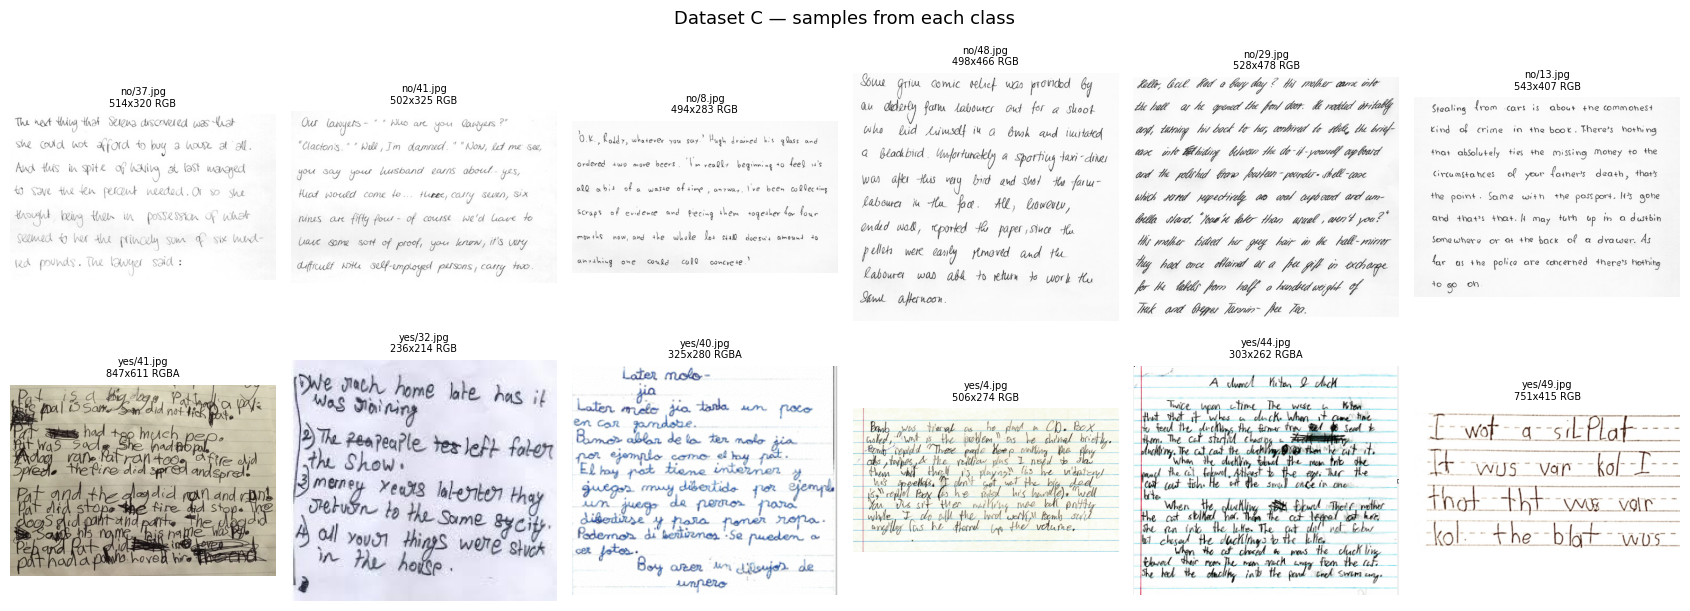

[saved] /content/drive/MyDrive/DyslexAI/results/figures/C_samples.png


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100

rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(2, 6, figsize=(17, 6.5))
for r, cls in enumerate(sorted(meta['class_name'].unique())):
    sub = meta[meta['class_name'] == cls]
    pick = rng.choice(len(sub), 6, replace=False)
    for c, i in enumerate(pick):
        row = sub.iloc[i]
        axes[r, c].imshow(Image.open(row['filepath']).convert('RGB'))
        axes[r, c].set_title(f'{cls}/{row["filename"]}\n{row["width"]}x{row["height"]} '
                             f'{row["mode"]}', fontsize=7)
        axes[r, c].axis('off')

fig.suptitle('Dataset C — samples from each class', fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'C_samples.png', bbox_inches='tight')
plt.show()
print(f'[saved] {FIGURES_DIR / "C_samples.png"}')

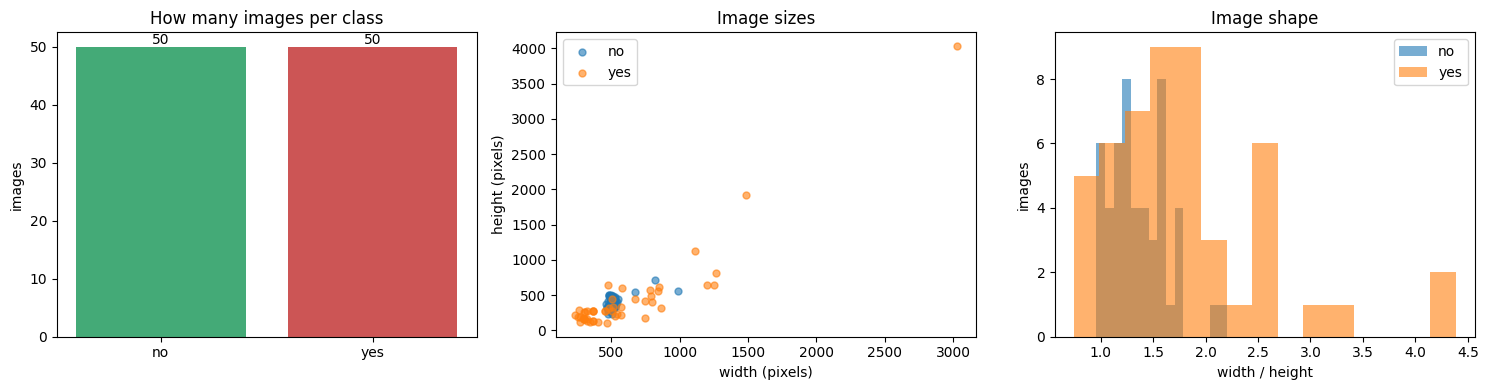

If the two colours separate cleanly in the middle plot, image size alone
tells you the class — which is the problem we test for next.


In [ ]:
# ---- Size and class distribution -------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

counts = meta['class_name'].value_counts().sort_index()
ax[0].bar(counts.index, counts.values, color=['#4a7', '#c55'])
ax[0].set_title('How many images per class'); ax[0].set_ylabel('images')
for i, v in enumerate(counts.values):
    ax[0].text(i, v, str(v), ha='center', va='bottom')

for cls, sub in meta.groupby('class_name'):
    ax[1].scatter(sub['width'], sub['height'], s=25, alpha=0.6, label=cls)
ax[1].set_xlabel('width (pixels)'); ax[1].set_ylabel('height (pixels)')
ax[1].set_title('Image sizes'); ax[1].legend()

for cls, sub in meta.groupby('class_name'):
    ax[2].hist(sub['aspect'], bins=15, alpha=0.6, label=cls)
ax[2].set_xlabel('width / height'); ax[2].set_ylabel('images')
ax[2].set_title('Image shape'); ax[2].legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'C_distributions.png', bbox_inches='tight')
plt.show()
print('If the two colours separate cleanly in the middle plot, image size alone')
print('tells you the class — which is the problem we test for next.')

---
# 5. CHECK 1 — Can you guess the class from image size alone?

We throw the pictures away completely. We keep only: width, height, shape, area, file size.

Then we ask a simple program to guess the class from just those numbers.

Whatever it scores is the **floor**. Any model we train later has to beat it clearly, or it has
not shown it learned anything from the handwriting.

We use cross-validation because the dataset is small: we split it five different ways and
average, so one lucky split does not fool us.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def floor_test(X, y, label):
    out = []
    for name, clf in [('LogisticRegression',
                       LogisticRegression(max_iter=3000, class_weight='balanced')),
                      ('RandomForest',
                       RandomForestClassifier(n_estimators=300, random_state=SEED,
                                              class_weight='balanced'))]:
        pipe = make_pipeline(StandardScaler(), clf)
        s = cross_val_score(pipe, X, y, cv=CV, scoring='balanced_accuracy')
        out.append({'check': label, 'model': name,
                    'balanced_accuracy': round(s.mean(), 3),
                    'spread': round(s.std(), 3)})
    return out


SIZE_FEATURES = ['width', 'height', 'aspect', 'area', 'file_size_bytes']
y = meta['label'].values

check1 = floor_test(meta[SIZE_FEATURES].values, y, 'size only')
print(pd.DataFrame(check1).to_string(index=False))
print('\nchance = 0.500')

FLOOR_SIZE = max(r['balanced_accuracy'] for r in check1)
print(f'\nSIZE FLOOR = {FLOOR_SIZE:.3f}')

    check              model  balanced_accuracy  spread
size only LogisticRegression               0.79   0.049
size only       RandomForest               0.89   0.049

chance = 0.500

SIZE FLOOR = 0.890


---
# 6. CHECK 2 — Does it survive when size is removed?

Now we take size out of the picture entirely. Every image is resized to the same 224×224 and
converted to the same colour format. After that, width and height carry no information at all.

Then we measure simple things about how the image *looks*, not what it says:

- **brightness** — how light or dark the paper is
- **contrast** — how much the ink stands out
- **colour** — whether the paper is warm or cool toned
- **ink coverage** — how much of the page has writing on it
- **sharpness** — how blurry or crisp the photo is

None of these is handwriting. A person cannot read a word from them.

If a program can still guess the class from these, the two classes were photographed or scanned
differently, and the dataset cannot fairly test handwriting.

In [ ]:
def appearance_features(path, size=224):
    """Simple facts about how an image looks, after removing all size information."""
    im = Image.open(path).convert('RGB').resize((size, size))
    a = np.asarray(im, dtype=np.float32)
    gray = a.mean(axis=2)

    # how much of the page is dark (roughly: how much ink)
    ink = (gray < gray.mean() - gray.std()).mean()

    # sharpness: how strong the edges are
    edges = np.asarray(im.convert('L').filter(ImageFilter.FIND_EDGES), dtype=np.float32)

    return {
        'brightness'   : float(gray.mean()),
        'contrast'     : float(gray.std()),
        'red_mean'     : float(a[:, :, 0].mean()),
        'green_mean'   : float(a[:, :, 1].mean()),
        'blue_mean'    : float(a[:, :, 2].mean()),
        'colour_spread': float(a.std(axis=(0, 1)).mean()),
        'ink_coverage' : float(ink),
        'edge_strength': float(edges.mean()),
        'edge_spread'  : float(edges.std()),
        'darkest'      : float(np.percentile(gray, 1)),
        'lightest'     : float(np.percentile(gray, 99)),
    }


app = pd.DataFrame([appearance_features(p) for p in meta['filepath']])
APP_FEATURES = list(app.columns)
print(f'measured {len(APP_FEATURES)} appearance features on {len(app)} images')

check2 = floor_test(app.values, y, 'appearance only (size removed)')
print()
print(pd.DataFrame(check2).to_string(index=False))
print('\nchance = 0.500')

FLOOR_APP = max(r['balanced_accuracy'] for r in check2)
print(f'\nAPPEARANCE FLOOR = {FLOOR_APP:.3f}')

measured 11 appearance features on 100 images

                         check              model  balanced_accuracy  spread
appearance only (size removed) LogisticRegression               0.91   0.037
appearance only (size removed)       RandomForest               0.88   0.068

chance = 0.500

APPEARANCE FLOOR = 0.910


In [ ]:
# ---- Which appearance feature gives it away? -------------------------------
single = []
for f in APP_FEATURES:
    pipe = make_pipeline(StandardScaler(),
                         LogisticRegression(max_iter=3000, class_weight='balanced'))
    s = cross_val_score(pipe, app[[f]].values, y, cv=CV, scoring='balanced_accuracy')
    single.append({'feature': f, 'balanced_accuracy': round(s.mean(), 3)})

single_df = pd.DataFrame(single).sort_values('balanced_accuracy', ascending=False)
print(single_df.to_string(index=False))
print('\nAnything well above 0.500 here is a difference in how the images were')
print('captured, not a difference in handwriting.')

      feature  balanced_accuracy
 ink_coverage               0.85
   green_mean               0.83
edge_strength               0.83
   brightness               0.81
     red_mean               0.81
    blue_mean               0.81
     contrast               0.79
colour_spread               0.79
      darkest               0.76
  edge_spread               0.68
     lightest               0.60

Anything well above 0.500 here is a difference in how the images were
captured, not a difference in handwriting.


---
# 7. The verdict

In [ ]:
verdict = pd.DataFrame(check1 + check2)
print(verdict.to_string(index=False))
print()
print(f'SIZE FLOOR       : {FLOOR_SIZE:.3f}')
print(f'APPEARANCE FLOOR : {FLOOR_APP:.3f}')
print(f'chance           : 0.500')
print()

if FLOOR_SIZE < 0.60 and FLOOR_APP < 0.60:
    print('VERDICT: clean. The classes are not separable without reading the')
    print('         handwriting. Safe to train and report normally.')
elif FLOOR_APP < 0.60:
    print('VERDICT: image SIZE gives the class away, but appearance does not.')
    print('         Workable: resize everything to the same size and report the')
    print('         appearance floor alongside every result.')
else:
    print('VERDICT: PROBLEM. The classes differ in how the images were captured,')
    print('         not only in size. A model can score highly without reading a')
    print('         single word.')
    print()
    print('         This dataset cannot fairly test handwriting classification.')
    print('         Any accuracy we report must be shown next to this floor, and')
    print('         we should say plainly that most of the score is available')
    print('         without the handwriting.')

                         check              model  balanced_accuracy  spread
                     size only LogisticRegression               0.79   0.049
                     size only       RandomForest               0.89   0.049
appearance only (size removed) LogisticRegression               0.91   0.037
appearance only (size removed)       RandomForest               0.88   0.068

SIZE FLOOR       : 0.890
APPEARANCE FLOOR : 0.910
chance           : 0.500

VERDICT: PROBLEM. The classes differ in how the images were captured,
         not only in size. A model can score highly without reading a
         single word.

         This dataset cannot fairly test handwriting classification.
         Any accuracy we report must be shown next to this floor, and
         we should say plainly that most of the score is available
         without the handwriting.


In [ ]:
# ---- Save everything --------------------------------------------------------
full = pd.concat([meta.reset_index(drop=True), app], axis=1)
full['participant_id'] = 'UNKNOWN'   # no writer information exists in this dataset

META_OUT = INTERIM_DIR / 'dataset_c_metadata.csv'
full.to_csv(META_OUT, index=False)

FLOOR_OUT = REPORTS_DIR / 'dataset_c_floor_checks.csv'
verdict.to_csv(FLOOR_OUT, index=False)

print(f'[saved] {META_OUT}   ({len(full)} rows)')
print(f'[saved] {FLOOR_OUT}')

[saved] /content/drive/MyDrive/DyslexAI/data/interim/dataset_c_metadata.csv   (100 rows)
[saved] /content/drive/MyDrive/DyslexAI/reports/dataset_c_floor_checks.csv


In [ ]:
report = f"""
{'='*70}
DATASET C - INSPECTION AND FAIRNESS CHECK
{'='*70}
Generated : {datetime.now().isoformat(timespec='seconds')}
Source    : Kaggle, Oussama Slmani - dyslexic handwriting
Jira      : DYS-5

WHAT THE IMAGES ARE
  Full sentences and paragraphs of English handwriting.
  This is a better match for the task than single characters.

COUNTS
  total images : {len(meta)}
  per class    : {meta['class_name'].value_counts().to_dict()}
  corrupted    : {int(meta['corrupted'].sum())}
  duplicates   : {len(meta) - meta['sha256'].nunique()}

DIFFERENCES BETWEEN THE CLASSES
{meta.groupby('class_name').agg(
    images=('filename','count'),
    median_area=('area','median'),
    min_width=('width','min'), max_width=('width','max'),
    median_aspect=('aspect','median'),
    with_camera_data=('has_exif','sum')).round(2).to_string()}

  colour formats:
{meta.groupby(['class_name','mode']).size().to_string()}

CAN YOU GUESS THE CLASS WITHOUT READING THE HANDWRITING?
{verdict.to_string(index=False)}

  size floor       : {FLOOR_SIZE:.3f}
  appearance floor : {FLOOR_APP:.3f}
  chance           : 0.500

WHAT GIVES IT AWAY MOST (appearance features)
{single_df.head(5).to_string(index=False)}

WRITER INFORMATION
  None. Filenames are plain numbers and appear in both folders.
  We cannot tell which images came from the same person, so we cannot
  keep one writer out of the test set. Recorded as UNKNOWN.

LIMITATIONS
  * {len(meta)} images is very small. A 15% test set is about {int(0.15*len(meta))} images,
    so one image moves the score by several points.
  * No writer information, so no writer-independent evaluation.
  * The two classes appear to come from different sources.
  * Yes/No are the labels the dataset came with. No diagnostic basis
    is documented. They are not diagnoses.
{'='*70}
""".strip()

print(report)
(REPORTS_DIR / 'dataset_c_inspection_report.txt').write_text(report)
print(f'\n[saved] {REPORTS_DIR / "dataset_c_inspection_report.txt"}')

DATASET C - INSPECTION AND FAIRNESS CHECK
Generated : 2026-09-27T19:59:21
Source    : Kaggle, Oussama Slmani - dyslexic handwriting
Jira      : DYS-5

WHAT THE IMAGES ARE
  Full sentences and paragraphs of English handwriting.
  This is a better match for the task than single characters.

COUNTS
  total images : 100
  per class    : {'no': 50, 'yes': 50}
  corrupted    : 0
  duplicates   : 0

DIFFERENCES BETWEEN THE CLASSES
            images  median_area  min_width  max_width  median_aspect  with_camera_data
class_name                                                                            
no              50     198628.0        463        990           1.33                 0
yes             50     125526.0        236       3024           1.62                10

  colour formats:
class_name  mode
no          RGB     50
yes         L        2
            P        5
            RGB     34
            RGBA     9

CAN YOU GUESS THE CLASS WITHOUT READING THE HANDWRITING?
               

---
# What to tell the supervisor

## What we did

Before training anything, we checked whether the dataset can fairly test handwriting. We asked
whether the class can be guessed without reading the handwriting at all — first from image size,
then from simple appearance measurements after all size information was removed.

## Why we do this first

If the two classes can be told apart without reading the writing, then any accuracy we report
later is partly meaningless. Finding that out before training saves the whole experiment.

## What to say

> The dataset is paragraph-level English handwriting, which is a better fit for the task than the
> single characters we tested previously. Before training we measured how much of the class can be
> predicted without reading the handwriting. We report that figure alongside every model result,
> so the reader can see how much of any score comes from the writing itself.

## Next steps

Depends on the verdict above.

**If both floors are low** — build the pipeline and train normally.

**If only the size floor is high** — resize everything to a fixed size, then proceed, reporting
the appearance floor beside every result.

**If both floors are high** — the dataset cannot fairly test handwriting. Still build the pipeline
on it, because that is useful practice for our own Urdu data, but report every result next to the
floor and say plainly what it means.

In all three cases we still gain the thing this phase is for: a working, reusable pipeline for
paragraph-level handwriting, ready for our own dataset.